In [1]:
from scipy.io import loadmat


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix


In [3]:
dreamer = loadmat(r'DREAMER.mat')


In [4]:
dreamer.keys()

dict_keys(['__header__', '__version__', '__globals__', 'DREAMER'])

In [8]:
type(dreamer['DREAMER'])
dreamer['DREAMER'].shape
dreamer['DREAMER'].dtype

dtype([('Data', 'O'), ('EEG_SamplingRate', 'O'), ('ECG_SamplingRate', 'O'), ('EEG_Electrodes', 'O'), ('noOfSubjects', 'O'), ('noOfVideoSequences', 'O'), ('Disclaimer', 'O'), ('Provider', 'O'), ('Version', 'O'), ('Acknowledgement', 'O')])

In [9]:
dreamer['DREAMER'].shape

(1, 1)

In [11]:
type(dreamer['DREAMER'])

numpy.ndarray

In [15]:
dreamer['DREAMER'].dtype.names

('Data',
 'EEG_SamplingRate',
 'ECG_SamplingRate',
 'EEG_Electrodes',
 'noOfSubjects',
 'noOfVideoSequences',
 'Disclaimer',
 'Provider',
 'Version',
 'Acknowledgement')

In [17]:
dreamer['DREAMER']['EEG_SamplingRate']

array([[array([[128]], dtype=uint8)]], dtype=object)

In [13]:
dreamer_struct = dreamer['DREAMER'][0, 0]
type(dreamer_struct)

numpy.void

In [14]:
dreamer_struct.dtype.names

('Data',
 'EEG_SamplingRate',
 'ECG_SamplingRate',
 'EEG_Electrodes',
 'noOfSubjects',
 'noOfVideoSequences',
 'Disclaimer',
 'Provider',
 'Version',
 'Acknowledgement')

In [18]:
data = dreamer_struct['Data']
type(data), data.shape

(numpy.ndarray, (1, 23))

In [19]:
subject = data[0]
type(subject), subject.dtype.names

(numpy.ndarray, None)

In [21]:
subject0 = data[0, 0]
type(subject0)

numpy.ndarray

In [22]:
subject0.dtype.names

('Age',
 'Gender',
 'EEG',
 'ECG',
 'ScoreValence',
 'ScoreArousal',
 'ScoreDominance')

In [23]:
dreamer_struct = dreamer['DREAMER'][0, 0]
data = dreamer_struct['Data']

print(type(data))
print(data.shape)

subject0 = data[0, 0]
print(type(subject0))
print(subject0.dtype.names)

<class 'numpy.ndarray'>
(1, 23)
<class 'numpy.ndarray'>
('Age', 'Gender', 'EEG', 'ECG', 'ScoreValence', 'ScoreArousal', 'ScoreDominance')


In [33]:
subject0['Age']

array([[array(['22'], dtype='<U2')]], dtype=object)

In [42]:
subject0['ScoreValence'][0][0]

array([[4],
       [3],
       [5],
       [4],
       [4],
       [1],
       [5],
       [1],
       [1],
       [5],
       [4],
       [4],
       [4],
       [3],
       [2],
       [3],
       [1],
       [3]], dtype=uint8)

In [45]:
import numpy as np

def unwrap_mat_cell(x):
    """
    Repeatedly unwrap 1-element object arrays/cells until we get
    the actual numeric/string content.
    """
    while isinstance(x, np.ndarray) and x.dtype == object and x.size == 1:
        x = x.item()
    return x

def to_1d_numeric(x):
    """
    Convert a nested MATLAB-loaded value into a clean 1D numeric array.
    """
    x = unwrap_mat_cell(x)
    x = np.array(x)
    x = np.squeeze(x)
    return x.reshape(-1).astype(float)

def to_scalar_or_string(x):
    """
    Convert nested MATLAB-loaded scalar/string into a normal Python value.
    """
    x = unwrap_mat_cell(x)
    x = np.array(x)
    x = np.squeeze(x)
    if x.shape == ():
        return x.item()
    return x

In [46]:
subj = data[0, 0]

age = to_scalar_or_string(subj['Age'])
gender = to_scalar_or_string(subj['Gender'])

valence = to_1d_numeric(subj['ScoreValence'])
arousal = to_1d_numeric(subj['ScoreArousal'])
dominance = to_1d_numeric(subj['ScoreDominance'])

print(age)
print(gender)
print(valence.shape)
print(valence)

22
male
(18,)
[4. 3. 5. 4. 4. 1. 5. 1. 1. 5. 4. 4. 4. 3. 2. 3. 1. 3.]


In [47]:
rows_trials = []

for subj_idx in range(data.shape[1]):
    subj = data[0, subj_idx]

    age = to_scalar_or_string(subj['Age'])
    gender = to_scalar_or_string(subj['Gender'])

    valence = to_1d_numeric(subj['ScoreValence'])
    arousal = to_1d_numeric(subj['ScoreArousal'])
    dominance = to_1d_numeric(subj['ScoreDominance'])

    n_trials = valence.shape[0]

    for trial_idx in range(n_trials):
        v = valence[trial_idx]
        a = arousal[trial_idx]
        d = dominance[trial_idx]

        stress_label = int((a >= 3.0) and (v <= 3.0))

        rows_trials.append({
            "subject_id": subj_idx + 1,
            "trial_id": trial_idx + 1,
            "age": age,
            "gender": gender,
            "valence": v,
            "arousal": a,
            "dominance": d,
            "stress_label": stress_label,
            "stress_rule": "arousal>=3 and valence<=3",
            "dataset": "DREAMER",
        })

df_trials = pd.DataFrame(rows_trials)
df_trials.head()

,subject_id,trial_id,age,gender,valence,arousal,dominance,stress_label,stress_rule,dataset
0,1,1,22,male,4.0,3.0,2.0,0,arousal>=3 and valence<=3,DREAMER
1,1,2,22,male,3.0,3.0,1.0,1,arousal>=3 and valence<=3,DREAMER
2,1,3,22,male,5.0,4.0,4.0,0,arousal>=3 and valence<=3,DREAMER
3,1,4,22,male,4.0,3.0,2.0,0,arousal>=3 and valence<=3,DREAMER
4,1,5,22,male,4.0,4.0,4.0,0,arousal>=3 and valence<=3,DREAMER


MAT file -> df_trials + df_raw_index -> df_bandpower -> df_features_wide -> modeling -> df_model_results

In [56]:
import numpy as np
import pandas as pd
from scipy.signal import welch

def unwrap_object_scalar(x):
    """
    Unwrap only object arrays of size 1.
    Do NOT unwrap structured arrays into tuples.
    """
    while isinstance(x, np.ndarray) and x.dtype == object and x.size == 1:
        x = x.item()
    return x

def to_1d_numeric(x):
    x = unwrap_object_scalar(x)
    x = np.array(x)
    x = np.squeeze(x)

    # if still object, unwrap each element
    if isinstance(x, np.ndarray) and x.dtype == object:
        flat = []
        for item in x.reshape(-1):
            item = unwrap_object_scalar(item)
            item = np.squeeze(np.array(item))
            if np.size(item) == 1:
                flat.append(float(item.item()))
            else:
                flat.append(float(np.array(item).reshape(-1)[0]))
        return np.array(flat, dtype=float)

    return np.array(x, dtype=float).reshape(-1)

def to_scalar_or_string(x):
    x = unwrap_object_scalar(x)
    x = np.squeeze(np.array(x))
    if np.size(x) == 1:
        return x.item()
    return x

def extract_dreamer_trials(x, which="stimuli"):
    """
    Extract list of trials from DREAMER subj['EEG'] or subj['ECG'].
    Handles baseline/stimuli nested MATLAB structure safely.
    """
    x = unwrap_object_scalar(x)

    # x may now be:
    # - structured ndarray with fields ('baseline','stimuli')
    # - numpy void record with fields
    # both support x[which]
    arr = x[which]

    arr = unwrap_object_scalar(arr)
    arr = np.squeeze(arr)

    trials = []

    if isinstance(arr, np.ndarray) and arr.dtype == object:
        for item in arr.reshape(-1):
            item = unwrap_object_scalar(item)
            item = np.squeeze(np.array(item, dtype=float))
            trials.append(item)
        return trials

    arr = np.array(arr, dtype=float)
    arr = np.squeeze(arr)

    if arr.ndim == 3:
        return [arr[i] for i in range(arr.shape[0])]
    elif arr.ndim == 2:
        return [arr]
    else:
        return [arr]

def compute_bandpower(signal, fs, band):
    fmin, fmax = band
    signal = np.asarray(signal, dtype=float).reshape(-1)

    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    mask = (freqs >= fmin) & (freqs < fmax)

    if not np.any(mask):
        return np.nan

    return np.trapz(psd[mask], freqs[mask])

In [53]:
bands = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
}

dreamer_struct = dreamer['DREAMER'][0, 0]

# sampling rate
fs = to_scalar_or_string(dreamer_struct['EEG_SamplingRate'])
fs = int(fs)

# channel names
raw_electrodes = unwrap_mat_cell(dreamer_struct['EEG_Electrodes'])
raw_electrodes = np.squeeze(raw_electrodes)

electrodes = []
for e in raw_electrodes.reshape(-1):
    e = unwrap_mat_cell(e)
    e = np.squeeze(np.array(e))
    if e.shape == ():
        electrodes.append(str(e.item()))
    else:
        electrodes.append(str(e))
        
print("fs:", fs)
print("electrodes:", electrodes)

fs: 128
electrodes: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']


In [58]:
dreamer_struct = dreamer['DREAMER'][0, 0]
data = dreamer_struct['Data']

fs = int(to_scalar_or_string(dreamer_struct['EEG_SamplingRate']))

raw_electrodes = unwrap_object_scalar(dreamer_struct['EEG_Electrodes'])
raw_electrodes = np.squeeze(raw_electrodes)

electrodes = []
for e in raw_electrodes.reshape(-1):
    e = unwrap_object_scalar(e)
    e = np.squeeze(np.array(e))
    electrodes.append(str(e.item()) if np.size(e) == 1 else str(e))

bands = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
}

rows_bandpower = []

for subj_idx in range(data.shape[1]):
    subj = data[0, subj_idx]

    age = to_scalar_or_string(subj['Age'])
    gender = to_scalar_or_string(subj['Gender'])

    valence = to_1d_numeric(subj['ScoreValence'])
    arousal = to_1d_numeric(subj['ScoreArousal'])
    dominance = to_1d_numeric(subj['ScoreDominance'])

    eeg_trials = extract_dreamer_trials(subj['EEG'], which="stimuli")

    n_trials = min(len(valence), len(arousal), len(dominance), len(eeg_trials))

    for trial_idx in range(n_trials):
        v = valence[trial_idx]
        a = arousal[trial_idx]
        d = dominance[trial_idx]

        stress_label = int((a >= 3.0) and (v <= 3.0))

        eeg = np.array(eeg_trials[trial_idx], dtype=float)
        eeg = np.squeeze(eeg)

        if eeg.ndim != 2:
            print(f"Skipping subject {subj_idx+1}, trial {trial_idx+1}: shape {eeg.shape}")
            continue

        # want channels x samples
        if eeg.shape[0] > eeg.shape[1]:
            eeg = eeg.T

        for ch_idx in range(eeg.shape[0]):
            channel_name = electrodes[ch_idx] if ch_idx < len(electrodes) else f"ch_{ch_idx+1}"
            signal = eeg[ch_idx]

            for band_name, band_range in bands.items():
                bp = compute_bandpower(signal, fs, band_range)

                rows_bandpower.append({
                    "subject_id": subj_idx + 1,
                    "trial_id": trial_idx + 1,
                    "age": age,
                    "gender": gender,
                    "valence": v,
                    "arousal": a,
                    "dominance": d,
                    "stress_label": stress_label,
                    "channel": channel_name,
                    "band": band_name,
                    "bandpower": bp
                })

df_bandpower = pd.DataFrame(rows_bandpower)
df_bandpower.head()

,subject_id,trial_id,age,gender,valence,arousal,dominance,stress_label,channel,band,bandpower
0,1,1,22,male,4.0,3.0,2.0,0,AF3,theta,5.147121
1,1,1,22,male,4.0,3.0,2.0,0,AF3,alpha,0.615457
2,1,1,22,male,4.0,3.0,2.0,0,AF3,beta,49.868303
3,1,1,22,male,4.0,3.0,2.0,0,F7,theta,19.517204
4,1,1,22,male,4.0,3.0,2.0,0,F7,alpha,1.758384


In [57]:
subj = data[0, 0]

eeg_trials = extract_dreamer_trials(subj['EEG'], which="stimuli")
print("num trials:", len(eeg_trials))
print("trial 1 shape:", np.array(eeg_trials[0]).shape)
print("trial 2 shape:", np.array(eeg_trials[1]).shape)

num trials: 18
trial 1 shape: (25472, 14)
trial 2 shape: (16768, 14)


In [60]:
df_features_wide = (
    df_bandpower
    .pivot_table(
        index=[
            "subject_id",
            "trial_id",
            "age",
            "gender",
            "valence",
            "arousal",
            "dominance",
            "stress_label"
        ],
        columns=["channel", "band"],
        values="bandpower",
        aggfunc="mean"
    )
    .reset_index()
)

df_features_wide.columns = [
    "_".join([str(c) for c in col if str(c) != ""]).strip("_")
    if isinstance(col, tuple) else col
    for col in df_features_wide.columns
]

df_features_wide.head()

,subject_id,trial_id,age,gender,valence,arousal,dominance,stress_label,AF3_alpha,AF3_beta,...,P7_theta,P8_alpha,P8_beta,P8_theta,T7_alpha,T7_beta,T7_theta,T8_alpha,T8_beta,T8_theta
0,1,1,22,male,4.0,3.0,2.0,0,0.615457,49.868303,...,130.480154,80.183591,316.977242,1168.500924,103.476103,1541.422300,1661.105754,111.986895,1909.706565,1735.076634
1,1,2,22,male,3.0,3.0,1.0,1,0.439899,46.577557,...,65.244225,71.783588,246.097946,579.862900,86.779471,802.106381,781.972783,96.932769,907.067976,808.240225
2,1,3,22,male,5.0,4.0,4.0,0,0.522750,46.019672,...,97.867166,192.219535,321.391525,867.189881,228.736681,789.827924,1086.380340,242.925857,872.032292,1135.440636
3,1,4,22,male,4.0,3.0,2.0,0,0.349941,41.950804,...,30.168216,49.242352,310.859532,353.094173,52.700899,1605.222427,512.770950,59.284017,2117.536582,612.972241
4,1,5,22,male,4.0,4.0,4.0,0,0.379860,50.747440,...,29.736645,74.278667,948.934392,430.619007,84.627424,4409.980494,772.107832,85.615786,5992.177429,944.496645


In [61]:
print(df_features_wide.shape)
print(df_features_wide.columns.tolist()[:15])

(414, 50)
['subject_id', 'trial_id', 'age', 'gender', 'valence', 'arousal', 'dominance', 'stress_label', 'AF3_alpha', 'AF3_beta', 'AF3_theta', 'AF4_alpha', 'AF4_beta', 'AF4_theta', 'F3_alpha']


In [62]:
df_features_wide.isna().sum().sort_values(ascending=False).head(10)

subject_id    0
O2_theta      0
FC5_beta      0
FC5_theta     0
FC6_alpha     0
FC6_beta      0
FC6_theta     0
O1_alpha      0
O1_beta       0
O1_theta      0
dtype: int64

In [63]:
id_cols = [
    "subject_id",
    "trial_id",
    "age",
    "gender",
    "valence",
    "arousal",
    "dominance",
    "stress_label"
]

feature_cols = [c for c in df_features_wide.columns if c not in id_cols]

X = df_features_wide[feature_cols]
y = df_features_wide["stress_label"]

print(X.shape)
print(y.shape)

(414, 42)
(414,)


In [66]:
# Build baseline bandpower in the same long format as df_bandpower
# ------------------------------------------------------------

rows_bandpower_baseline = []

for subj_idx in range(data.shape[1]):
    subj = data[0, subj_idx]

    age = to_scalar_or_string(subj['Age'])
    gender = to_scalar_or_string(subj['Gender'])

    valence = to_1d_numeric(subj['ScoreValence'])
    arousal = to_1d_numeric(subj['ScoreArousal'])
    dominance = to_1d_numeric(subj['ScoreDominance'])

    eeg_trials_baseline = extract_dreamer_trials(subj['EEG'], which="baseline")

    n_trials = min(len(valence), len(arousal), len(dominance), len(eeg_trials_baseline))

    for trial_idx in range(n_trials):
        v = valence[trial_idx]
        a = arousal[trial_idx]
        d = dominance[trial_idx]

        stress_label = int((a >= 3.0) and (v <= 3.0))

        eeg = np.array(eeg_trials_baseline[trial_idx], dtype=float)
        eeg = np.squeeze(eeg)

        if eeg.ndim != 2:
            print(f"Skipping BASELINE subject {subj_idx+1}, trial {trial_idx+1}: shape {eeg.shape}")
            continue

        # want channels x samples
        if eeg.shape[0] > eeg.shape[1]:
            eeg = eeg.T

        for ch_idx in range(eeg.shape[0]):
            channel_name = electrodes[ch_idx] if ch_idx < len(electrodes) else f"ch_{ch_idx+1}"
            signal = eeg[ch_idx]

            for band_name, band_range in bands.items():
                bp = compute_bandpower(signal, fs, band_range)

                rows_bandpower_baseline.append({
                    "subject_id": subj_idx + 1,
                    "trial_id": trial_idx + 1,
                    "age": age,
                    "gender": gender,
                    "valence": v,
                    "arousal": a,
                    "dominance": d,
                    "stress_label": stress_label,
                    "channel": channel_name,
                    "band": band_name,
                    "bandpower_baseline": bp
                })

df_bandpower_baseline = pd.DataFrame(rows_bandpower_baseline)

print("df_bandpower_baseline shape:", df_bandpower_baseline.shape)
df_bandpower_baseline.head()

df_bandpower_baseline shape: (17388, 11)


,subject_id,trial_id,age,gender,valence,arousal,dominance,stress_label,channel,band,bandpower_baseline
0,1,1,22,male,4.0,3.0,2.0,0,AF3,theta,9.903642
1,1,1,22,male,4.0,3.0,2.0,0,AF3,alpha,0.663523
2,1,1,22,male,4.0,3.0,2.0,0,AF3,beta,52.011924
3,1,1,22,male,4.0,3.0,2.0,0,F7,theta,37.031680
4,1,1,22,male,4.0,3.0,2.0,0,F7,alpha,2.048025


In [67]:
# ------------------------------------------------------------
# 2) Rename current stimuli bandpower and merge with baseline
# ------------------------------------------------------------

df_bandpower_stimuli = df_bandpower.rename(columns={"bandpower": "bandpower_stimuli"}).copy()

merge_cols = [
    "subject_id", "trial_id", "age", "gender",
    "valence", "arousal", "dominance", "stress_label",
    "channel", "band"
]

df_bandpower_corrected = pd.merge(
    df_bandpower_stimuli,
    df_bandpower_baseline,
    on=merge_cols,
    how="inner"
)

eps = 1e-8

df_bandpower_corrected["bandpower_diff"] = (
    df_bandpower_corrected["bandpower_stimuli"] - df_bandpower_corrected["bandpower_baseline"]
)

df_bandpower_corrected["bandpower_logratio"] = np.log(
    (df_bandpower_corrected["bandpower_stimuli"] + eps) /
    (df_bandpower_corrected["bandpower_baseline"] + eps)
)

print("df_bandpower_corrected shape:", df_bandpower_corrected.shape)
df_bandpower_corrected.head()

df_bandpower_corrected shape: (17388, 14)


,subject_id,trial_id,age,gender,valence,arousal,dominance,stress_label,channel,band,bandpower_stimuli,bandpower_baseline,bandpower_diff,bandpower_logratio
0,1,1,22,male,4.0,3.0,2.0,0,AF3,theta,5.147121,9.903642,-4.756521,-0.654465
1,1,1,22,male,4.0,3.0,2.0,0,AF3,alpha,0.615457,0.663523,-0.048065,-0.075197
2,1,1,22,male,4.0,3.0,2.0,0,AF3,beta,49.868303,52.011924,-2.143621,-0.042087
3,1,1,22,male,4.0,3.0,2.0,0,F7,theta,19.517204,37.031680,-17.514476,-0.640477
4,1,1,22,male,4.0,3.0,2.0,0,F7,alpha,1.758384,2.048025,-0.289641,-0.152481


In [68]:
# ------------------------------------------------------------
# 3) Make wide feature tables
#    - raw stimuli features
#    - baseline difference features
#    - baseline log-ratio features
# ------------------------------------------------------------

index_cols = [
    "subject_id", "trial_id", "age", "gender",
    "valence", "arousal", "dominance", "stress_label"
]

df_features_wide_raw = (
    df_bandpower_stimuli
    .pivot_table(
        index=index_cols,
        columns=["channel", "band"],
        values="bandpower_stimuli",
        aggfunc="mean"
    )
    .reset_index()
)

df_features_wide_diff = (
    df_bandpower_corrected
    .pivot_table(
        index=index_cols,
        columns=["channel", "band"],
        values="bandpower_diff",
        aggfunc="mean"
    )
    .reset_index()
)

df_features_wide_logratio = (
    df_bandpower_corrected
    .pivot_table(
        index=index_cols,
        columns=["channel", "band"],
        values="bandpower_logratio",
        aggfunc="mean"
    )
    .reset_index()
)

def flatten_columns(df):
    df = df.copy()
    df.columns = [
        "_".join([str(c) for c in col if str(c) != ""]).strip("_")
        if isinstance(col, tuple) else col
        for col in df.columns
    ]
    return df

df_features_wide_raw = flatten_columns(df_features_wide_raw)
df_features_wide_diff = flatten_columns(df_features_wide_diff)
df_features_wide_logratio = flatten_columns(df_features_wide_logratio)

print("raw shape:", df_features_wide_raw.shape)
print("diff shape:", df_features_wide_diff.shape)
print("logratio shape:", df_features_wide_logratio.shape)

df_features_wide_logratio.head()

raw shape: (414, 50)
diff shape: (414, 50)
logratio shape: (414, 50)


,subject_id,trial_id,age,gender,valence,arousal,dominance,stress_label,AF3_alpha,AF3_beta,...,P7_theta,P8_alpha,P8_beta,P8_theta,T7_alpha,T7_beta,T7_theta,T8_alpha,T8_beta,T8_theta
0,1,1,22,male,4.0,3.0,2.0,0,-0.075197,-0.042087,...,-0.466502,-0.035687,-0.389445,-0.543264,-0.054216,-0.839826,-0.562491,-0.017584,-0.876283,-0.583552
1,1,2,22,male,3.0,3.0,1.0,1,-0.065769,-0.065670,...,-0.092417,0.095792,0.053150,-0.138833,0.023923,0.196314,-0.173769,0.027503,0.194271,-0.194361
2,1,3,22,male,5.0,4.0,4.0,0,0.150471,0.034108,...,-0.251814,0.701253,0.277057,-0.164516,0.647432,0.139465,-0.170650,0.582483,0.094100,-0.175458
3,1,4,22,male,4.0,3.0,2.0,0,-0.158331,-0.165210,...,-0.159297,0.127656,-0.210830,-0.052891,0.037021,-0.330478,-0.174528,0.139509,-0.352460,-0.193176
4,1,5,22,male,4.0,4.0,4.0,0,0.010413,0.151354,...,-0.487092,-0.325878,0.848602,-0.286128,-0.322828,0.723272,0.009418,-0.316876,0.700626,0.033164


In [77]:
# ------------------------------------------------------------
# 4) Build feature maps for interpretability
# ------------------------------------------------------------

meta_cols = [
    "subject_id", "trial_id", "age", "gender",
    "valence", "arousal", "dominance", "stress_label"
]

def build_feature_map(df_wide):
    feature_cols = [c for c in df_wide.columns if c not in meta_cols]
    fmap = pd.DataFrame({"feature": feature_cols})
    fmap["channel"] = fmap["feature"].apply(lambda x: x.rsplit("_", 1)[0])
    fmap["band"] = fmap["feature"].apply(lambda x: x.rsplit("_", 1)[1])
    return fmap

df_feature_map_raw = build_feature_map(df_features_wide_raw)
df_feature_map_diff = build_feature_map(df_features_wide_diff)
df_feature_map_logratio = build_feature_map(df_features_wide_logratio)

def channel_region(ch):
    ch = ch.upper()
    if ch.startswith("FP") or ch.startswith("AF") or ch.startswith("F"):
        return "frontal"
    elif ch.startswith("FC") or ch.startswith("C"):
        return "central"
    elif ch.startswith("T"):
        return "temporal"
    elif ch.startswith("P"):
        return "parietal"
    elif ch.startswith("O"):
        return "occipital"
    else:
        return "other"

for fmap in [df_feature_map_raw, df_feature_map_diff, df_feature_map_logratio]:
    fmap["region"] = fmap["channel"].apply(channel_region)

df_feature_map_logratio.head()

df_feature_map_logratio.head()

,feature,channel,band,region
0,AF3_alpha,AF3,alpha,frontal
1,AF3_beta,AF3,beta,frontal
2,AF3_theta,AF3,theta,frontal
3,AF4_alpha,AF4,alpha,frontal
4,AF4_beta,AF4,beta,frontal


In [71]:
# ------------------------------------------------------------
# 6) Per-subject LDA evaluation
#    sklearn-ready features,
#    LDA, stratified CV, ROC/AUC, subject-wise analysis.
# ------------------------------------------------------------

def evaluate_subjectwise_lda(
    df_wide,
    feature_set_name="logratio",
    n_splits=3,
    random_state=189
):
    meta_cols = [
        "subject_id", "trial_id", "age", "gender",
        "valence", "arousal", "dominance", "stress_label"
    ]
    feature_cols = [c for c in df_wide.columns if c not in meta_cols]

    fold_rows = []
    subject_rows = []
    roc_payload = {}

    subjects = sorted(df_wide["subject_id"].unique())

    for subject_id in subjects:
        df_sub = df_wide[df_wide["subject_id"] == subject_id].copy()

        X = df_sub[feature_cols].to_numpy(dtype=float)
        y = df_sub["stress_label"].to_numpy(dtype=int)

        # skip subjects without both classes
        if len(np.unique(y)) < 2:
            print(f"Skipping subject {subject_id}: only one class present")
            continue

        # make sure each class has enough samples for n_splits
        class_counts = pd.Series(y).value_counts()
        if class_counts.min() < n_splits:
            print(f"Skipping subject {subject_id}: not enough samples per class for {n_splits}-fold CV")
            continue

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

        clf = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")

        subject_accs = []
        subject_aucs = []
        subject_confmats = []

        tprs = []
        aucs = []
        mean_fpr = np.linspace(0, 1, 100)

        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            clf.fit(X_train, y_train)

            y_pred = clf.predict(X_test)
            y_proba = clf.predict_proba(X_test)[:, 1]

            acc = accuracy_score(y_test, y_pred)
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            fold_auc = auc(fpr, tpr)
            cm = confusion_matrix(y_test, y_pred)

            subject_accs.append(acc)
            subject_aucs.append(fold_auc)
            subject_confmats.append(cm)

            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)
            aucs.append(fold_auc)

            fold_rows.append({
                "subject_id": subject_id,
                "feature_set": feature_set_name,
                "model": "LDA",
                "fold": fold_idx,
                "accuracy": acc,
                "auc": fold_auc,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "n_train_stress": int(y_train.sum()),
                "n_test_stress": int(y_test.sum())
            })

        subject_rows.append({
            "subject_id": subject_id,
            "feature_set": feature_set_name,
            "model": "LDA",
            "mean_accuracy": float(np.mean(subject_accs)),
            "std_accuracy": float(np.std(subject_accs)),
            "mean_auc": float(np.mean(subject_aucs)),
            "std_auc": float(np.std(subject_aucs)),
            "n_trials": int(len(y)),
            "n_stress": int(y.sum()),
            "n_nonstress": int((y == 0).sum())
        })

        roc_payload[subject_id] = {
            "mean_fpr": mean_fpr,
            "tprs": tprs,
            "aucs": aucs
        }

    df_fold_results = pd.DataFrame(fold_rows)
    df_subject_results = pd.DataFrame(subject_rows)

    return df_fold_results, df_subject_results, roc_payload

In [72]:
# ------------------------------------------------------------
# 7) Run the main evaluation on raw, diff, and log-ratio features
# ------------------------------------------------------------

df_fold_results_raw, df_subject_results_raw, roc_raw = evaluate_subjectwise_lda(
    df_features_wide_raw,
    feature_set_name="raw",
    n_splits=3,
    random_state=189
)

df_fold_results_diff, df_subject_results_diff, roc_diff = evaluate_subjectwise_lda(
    df_features_wide_diff,
    feature_set_name="diff",
    n_splits=3,
    random_state=189
)

df_fold_results_logratio, df_subject_results_logratio, roc_logratio = evaluate_subjectwise_lda(
    df_features_wide_logratio,
    feature_set_name="logratio",
    n_splits=3,
    random_state=189
)

df_subject_results_all = pd.concat(
    [df_subject_results_raw, df_subject_results_diff, df_subject_results_logratio],
    ignore_index=True
)

df_fold_results_all = pd.concat(
    [df_fold_results_raw, df_fold_results_diff, df_fold_results_logratio],
    ignore_index=True
)

print("Subject-level summary:")
display(df_subject_results_all)

print("\nOverall mean performance by feature set:")
display(
    df_subject_results_all.groupby("feature_set")[["mean_accuracy", "mean_auc"]].mean().sort_values("mean_auc", ascending=False)
)

Skipping subject 10: not enough samples per class for 3-fold CV
Skipping subject 10: not enough samples per class for 3-fold CV
Skipping subject 10: not enough samples per class for 3-fold CV
Subject-level summary:


,subject_id,feature_set,model,mean_accuracy,std_accuracy,mean_auc,std_auc,n_trials,n_stress,n_nonstress
0,1,raw,LDA,0.833333,0.000000,0.600000,0.163299,18,3,15
1,2,raw,LDA,0.722222,0.157135,0.761574,0.180763,18,11,7
2,3,raw,LDA,0.833333,0.136083,0.958333,0.058926,18,6,12
3,4,raw,LDA,0.333333,0.136083,0.074074,0.104757,18,8,10
4,5,raw,LDA,0.444444,0.078567,0.351852,0.114156,18,10,8
...,...,...,...,...,...,...,...,...,...,...
61,19,logratio,LDA,0.555556,0.078567,0.310185,0.064483,18,8,10
62,20,logratio,LDA,0.388889,0.157135,0.347222,0.019642,18,8,10
63,21,logratio,LDA,0.611111,0.157135,0.685185,0.091662,18,11,7
64,22,logratio,LDA,0.500000,0.136083,0.208333,0.212459,18,6,12



Overall mean performance by feature set:


,mean_accuracy,mean_auc
feature_set,,
raw,0.565657,0.582934
diff,0.583333,0.575210
logratio,0.568182,0.539352


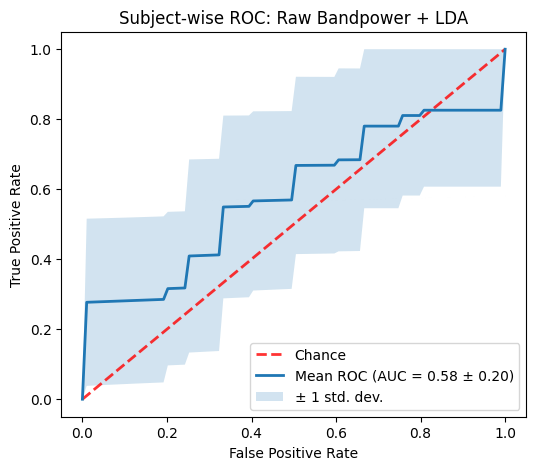

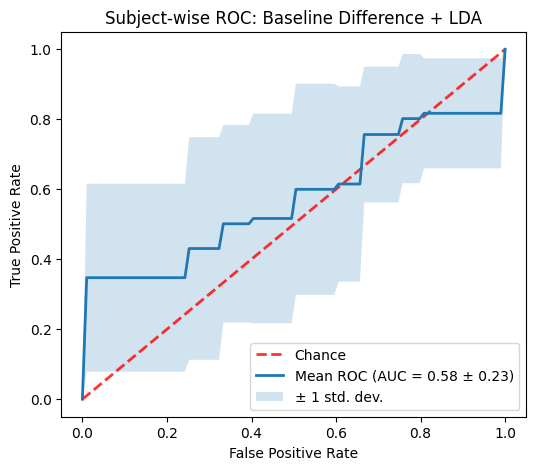

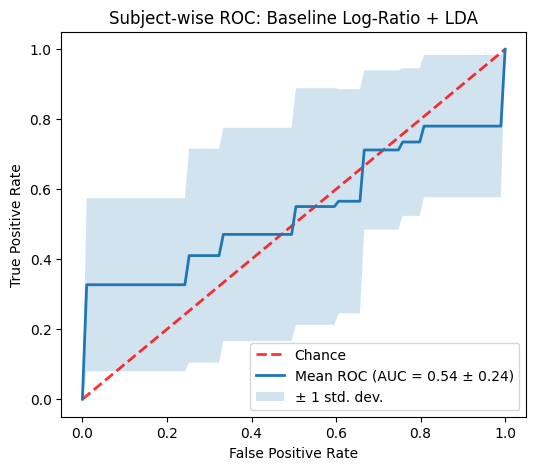

In [73]:
# ------------------------------------------------------------
# 8) Plot one mean ROC curve per feature set
# ------------------------------------------------------------

def plot_mean_roc_from_subject_payload(roc_payload, title):
    plt.figure(figsize=(6, 5))

    all_mean_tprs = []
    all_mean_aucs = []
    reference_fpr = None

    for subject_id, payload in roc_payload.items():
        mean_fpr = payload["mean_fpr"]
        tprs = payload["tprs"]
        aucs = payload["aucs"]

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0

        all_mean_tprs.append(mean_tpr)
        all_mean_aucs.append(np.mean(aucs))
        reference_fpr = mean_fpr

    if len(all_mean_tprs) == 0:
        print("No valid ROC data to plot.")
        return

    grand_mean_tpr = np.mean(all_mean_tprs, axis=0)
    grand_std_tpr = np.std(all_mean_tprs, axis=0)
    grand_mean_auc = np.mean(all_mean_aucs)
    grand_std_auc = np.std(all_mean_aucs)

    plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", alpha=0.8, label="Chance")
    plt.plot(
        reference_fpr,
        grand_mean_tpr,
        lw=2,
        label=f"Mean ROC (AUC = {grand_mean_auc:.2f} ± {grand_std_auc:.2f})"
    )
    plt.fill_between(
        reference_fpr,
        np.maximum(grand_mean_tpr - grand_std_tpr, 0),
        np.minimum(grand_mean_tpr + grand_std_tpr, 1),
        alpha=0.2,
        label="± 1 std. dev."
    )

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

plot_mean_roc_from_subject_payload(roc_raw, "Subject-wise ROC: Raw Bandpower + LDA")
plot_mean_roc_from_subject_payload(roc_diff, "Subject-wise ROC: Baseline Difference + LDA")
plot_mean_roc_from_subject_payload(roc_logratio, "Subject-wise ROC: Baseline Log-Ratio + LDA")

In [74]:
# ------------------------------------------------------------
# 9) Fit one pooled LDA model on log-ratio features to inspect coefficients
#    This is for interpretability by feature/channel/band/region.
# ------------------------------------------------------------

meta_cols = [
    "subject_id", "trial_id", "age", "gender",
    "valence", "arousal", "dominance", "stress_label"
]
feature_cols_logratio = [c for c in df_features_wide_logratio.columns if c not in meta_cols]

X_all = df_features_wide_logratio[feature_cols_logratio].to_numpy(dtype=float)
y_all = df_features_wide_logratio["stress_label"].to_numpy(dtype=int)

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

clf_all = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
clf_all.fit(X_all_scaled, y_all)

lda_coef = np.abs(clf_all.coef_[0])

df_feature_importance = pd.DataFrame({
    "feature": feature_cols_logratio,
    "lda_abs_coef": lda_coef
}).merge(df_feature_map_logratio, on="feature", how="left")

display(df_feature_importance.sort_values("lda_abs_coef", ascending=False).head(15))

,feature,lda_abs_coef,channel,band,region
4,AF4_beta,0.500681,AF4,beta,frontal
9,F4_alpha,0.481674,F4,alpha,frontal
28,O2_beta,0.370177,O2,beta,occipital
34,P8_beta,0.357087,P8,beta,parietal
12,F7_alpha,0.311250,F7,alpha,frontal
31,P7_beta,0.304452,P7,beta,parietal
17,F8_theta,0.293678,F8,theta,frontal
7,F3_beta,0.261950,F3,beta,frontal
2,AF3_theta,0.238985,AF3,theta,frontal
19,FC5_beta,0.226535,FC5,beta,frontal


In [75]:
# ------------------------------------------------------------
# 10) Summaries of importance by band, channel, and region
# ------------------------------------------------------------

print("Importance by band:")
display(
    df_feature_importance
    .groupby("band", as_index=False)["lda_abs_coef"]
    .mean()
    .sort_values("lda_abs_coef", ascending=False)
)

print("Top channels by mean importance:")
display(
    df_feature_importance
    .groupby("channel", as_index=False)["lda_abs_coef"]
    .mean()
    .sort_values("lda_abs_coef", ascending=False)
    .head(10)
)

print("Importance by region:")
display(
    df_feature_importance
    .groupby("region", as_index=False)["lda_abs_coef"]
    .mean()
    .sort_values("lda_abs_coef", ascending=False)
)

Importance by band:


,band,lda_abs_coef
1,beta,0.217613
0,alpha,0.141911
2,theta,0.118448


Top channels by mean importance:


,channel,lda_abs_coef
10,P7,0.227308
3,F4,0.214290
1,AF4,0.197763
11,P8,0.194558
0,AF3,0.184235
4,F7,0.178721
8,O1,0.172297
9,O2,0.172218
6,FC5,0.166612
5,F8,0.142026


Importance by region:


,region,lda_abs_coef
2,parietal,0.210933
1,occipital,0.172258
0,frontal,0.159578
3,temporal,0.093766


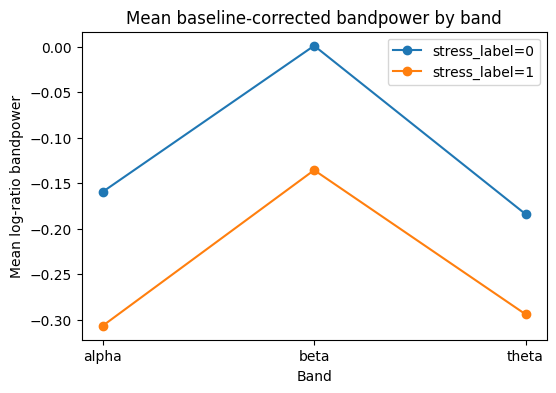

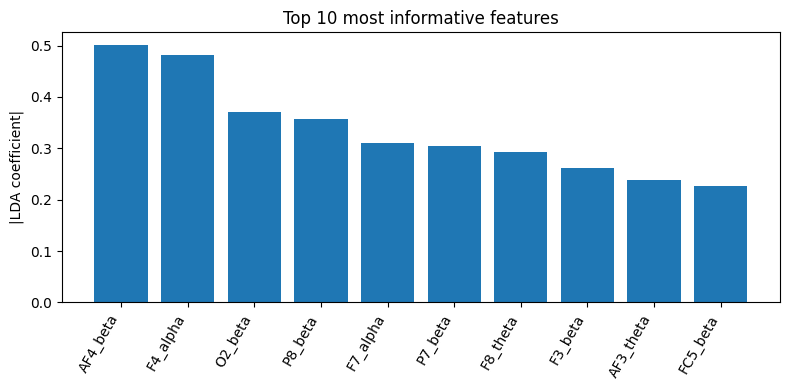

In [76]:
# ------------------------------------------------------------
# 11) plots
# ------------------------------------------------------------

# Mean corrected bandpower by band and label
summary_band = (
    df_bandpower_corrected
    .groupby(["band", "stress_label"], as_index=False)["bandpower_logratio"]
    .mean()
)

plt.figure(figsize=(6, 4))
for label in sorted(summary_band["stress_label"].unique()):
    sub = summary_band[summary_band["stress_label"] == label]
    plt.plot(sub["band"], sub["bandpower_logratio"], marker="o", label=f"stress_label={label}")
plt.xlabel("Band")
plt.ylabel("Mean log-ratio bandpower")
plt.title("Mean baseline-corrected bandpower by band")
plt.legend()
plt.show()

# Top 10 features by LDA coefficient
top10 = df_feature_importance.sort_values("lda_abs_coef", ascending=False).head(10)

plt.figure(figsize=(8, 4))
plt.bar(top10["feature"], top10["lda_abs_coef"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("|LDA coefficient|")
plt.title("Top 10 most informative features")
plt.tight_layout()
plt.show()